In [82]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn import tree
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, 
    f1_score, classification_report, confusion_matrix
)
import numpy as np

In [83]:
import sys
!{sys.executable} -m pip install xgboost

  Using cached xgboost-3.2.0-py3-none-win_amd64.whl.metadata (2.1 kB)
Using cached xgboost-3.2.0-py3-none-win_amd64.whl (101.7 MB)


In [52]:
data = pd.read_csv("../artifacts/processed.csv")
data.head()

,Unnamed: 0,accident_type,day_of_week,dca_code,no_of_vehicles,police_attended,road_geometry,light_condition,speed_zone,severity,node_type,deg_urban_name,road_type,total_vehicles,max_vehicle_damage,total_persons,year,month,hour
0,0,4,1,171,1,1,5,5,100.0,0,N,RURAL_VICTORIA,ROAD,1,5.0,2,2012,1,2
1,1,1,1,110,2,1,1,3,80.0,0,N,MELB_URBAN,ROAD,2,4.0,3,2012,1,2
2,2,1,1,160,2,1,2,3,60.0,0,I,MELB_URBAN,ROAD,2,4.0,1,2012,1,3
3,3,4,1,173,1,1,1,5,100.0,0,I,RURAL_VICTORIA,HIGHWAY,1,5.0,1,2012,1,5
4,4,4,1,171,1,1,5,1,50.0,0,N,MELB_URBAN,ROAD,1,3.0,3,2012,1,7


In [53]:
data = data.iloc[:,1:]
data.head()

,accident_type,day_of_week,dca_code,no_of_vehicles,police_attended,road_geometry,light_condition,speed_zone,severity,node_type,deg_urban_name,road_type,total_vehicles,max_vehicle_damage,total_persons,year,month,hour
0,4,1,171,1,1,5,5,100.0,0,N,RURAL_VICTORIA,ROAD,1,5.0,2,2012,1,2
1,1,1,110,2,1,1,3,80.0,0,N,MELB_URBAN,ROAD,2,4.0,3,2012,1,2
2,1,1,160,2,1,2,3,60.0,0,I,MELB_URBAN,ROAD,2,4.0,1,2012,1,3
3,4,1,173,1,1,1,5,100.0,0,I,RURAL_VICTORIA,HIGHWAY,1,5.0,1,2012,1,5
4,4,1,171,1,1,5,1,50.0,0,N,MELB_URBAN,ROAD,1,3.0,3,2012,1,7


In [4]:
data.dtypes

accident_type           int64
day_of_week             int64
dca_code               object
no_of_vehicles          int64
police_attended         int64
road_geometry           int64
light_condition         int64
speed_zone            float64
severity                int64
node_type              object
deg_urban_name         object
road_type              object
total_vehicles          int64
max_vehicle_damage    float64
total_persons           int64
year                    int64
month                   int64
hour                    int64
dtype: object

In [54]:
features = ["accident_type", "day_of_week", "dca_code", "road_geometry", "light_condition", "speed_zone", "severity", "node_type", "deg_urban_name", "road_type", "month", "hour"]

df = data[features]
df.head()

,accident_type,day_of_week,dca_code,road_geometry,light_condition,speed_zone,severity,node_type,deg_urban_name,road_type,month,hour
0,4,1,171,5,5,100.0,0,N,RURAL_VICTORIA,ROAD,1,2
1,1,1,110,1,3,80.0,0,N,MELB_URBAN,ROAD,1,2
2,1,1,160,2,3,60.0,0,I,MELB_URBAN,ROAD,1,3
3,4,1,173,1,5,100.0,0,I,RURAL_VICTORIA,HIGHWAY,1,5
4,4,1,171,5,1,50.0,0,N,MELB_URBAN,ROAD,1,7


In [7]:
for f in features: 
    print(f"Value counts for {f} : {df[f].value_counts()}")

Value counts for accident_type : accident_type
1    124694
4     28797
2     15790
6      9017
8      7925
3      2095
5      2012
7      1240
9       209
Name: count, dtype: int64
Value counts for day_of_week : day_of_week
5    29434
6    29052
4    28611
3    27967
2    26623
1    24119
7    21200
0     4773
Name: count, dtype: int64
Value counts for dca_code : dca_code
130      34715
OTHER    31497
121      16480
110      13716
171      10817
113       8915
174       7501
173       7487
120       6135
100       6065
181       5051
160       4765
147       3973
102       3937
183       3568
132       3510
140       3186
116       2700
135       2664
111       2572
133       2226
184       2091
163       2089
167       2087
170       2072
134       1960
Name: count, dtype: int64
Value counts for road_geometry : road_geometry
5    99419
1    44128
2    43437
4     3667
3      663
9      273
6      175
8       11
7        6
Name: count, dtype: int64
Value counts for light_condition : li

In [55]:
df["dca_code"] = df["dca_code"].replace("OTHER", 99)
df["dca_code"].value_counts()

C:\Users\Admin\AppData\Local\Temp\ipykernel_30576\3324226956.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["dca_code"] = df["dca_code"].replace("OTHER", 99)


dca_code
130    34715
99     31497
121    16480
110    13716
171    10817
113     8915
174     7501
173     7487
120     6135
100     6065
181     5051
160     4765
147     3973
102     3937
183     3568
132     3510
140     3186
116     2700
135     2664
111     2572
133     2226
184     2091
163     2089
167     2087
170     2072
134     1960
Name: count, dtype: int64

In [9]:
df["dca_code"].value_counts(normalize=True)

dca_code
130    0.181016
99     0.164236
121    0.085932
110    0.071520
171    0.056403
113    0.046486
174    0.039113
173    0.039040
120    0.031990
100    0.031625
181    0.026338
160    0.024846
147    0.020717
102    0.020529
183    0.018605
132    0.018302
140    0.016613
116    0.014079
135    0.013891
111    0.013411
133    0.011607
184    0.010903
163    0.010893
167    0.010882
170    0.010804
134    0.010220
Name: proportion, dtype: float64

In [56]:
# categorical features
categorical_cols = [
    "accident_type",
    "day_of_week",
    "dca_code",
    "road_geometry",
    "light_condition",
    "node_type",
    "deg_urban_name",
    "road_type",
    "month"
]

# numeric features
numeric_cols = [
    "speed_zone",
    "hour"
]

# target
target_col = "severity"


# convert types
df[categorical_cols] = df[categorical_cols].astype("category")
df[numeric_cols] = df[numeric_cols].astype("float64")  # or int if you prefer
#df[target_col] = df[target_col].astype("category")

C:\Users\Admin\AppData\Local\Temp\ipykernel_30576\2574348852.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[categorical_cols] = df[categorical_cols].astype("category")
C:\Users\Admin\AppData\Local\Temp\ipykernel_30576\2574348852.py:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[numeric_cols] = df[numeric_cols].astype("float64")  # or int if you prefer


In [57]:
df.dtypes

accident_type      category
day_of_week        category
dca_code           category
road_geometry      category
light_condition    category
speed_zone          float64
severity              int64
node_type          category
deg_urban_name     category
road_type          category
month              category
hour                float64
dtype: object

In [13]:
df.to_csv("model_ready_data.csv")

In [59]:
df = pd.get_dummies(df, drop_first=True)

In [60]:
df.head()

,speed_zone,severity,hour,accident_type_2,accident_type_3,accident_type_4,accident_type_5,accident_type_6,accident_type_7,accident_type_8,...,month_3,month_4,month_5,month_6,month_7,month_8,month_9,month_10,month_11,month_12
0,100.0,0,2.0,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,80.0,0,2.0,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,60.0,0,3.0,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,100.0,0,5.0,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,50.0,0,7.0,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [61]:
y = df[target_col]
y.head()

0    0
1    0
2    0
3    0
4    0
Name: severity, dtype: int64

In [62]:
X = df.drop(columns = target_col)
X.head()

,speed_zone,hour,accident_type_2,accident_type_3,accident_type_4,accident_type_5,accident_type_6,accident_type_7,accident_type_8,accident_type_9,...,month_3,month_4,month_5,month_6,month_7,month_8,month_9,month_10,month_11,month_12
0,100.0,2.0,False,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,80.0,2.0,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,60.0,3.0,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,100.0,5.0,False,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,50.0,7.0,False,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [63]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 19)

In [64]:
model = tree.DecisionTreeClassifier()
model.fit(X_train, y_train)

DecisionTreeClassifier()

In [65]:
y_pred = model.predict(X_test)

In [69]:
print(accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

0.9666284284075504
              precision    recall  f1-score   support

           0       0.98      0.98      0.98     37702
           1       0.06      0.06      0.06       654

    accuracy                           0.97     38356
   macro avg       0.52      0.52      0.52     38356
weighted avg       0.97      0.97      0.97     38356



In [77]:
model2 = tree.DecisionTreeClassifier(
    class_weight='balanced',
    criterion='entropy',        # 'entropy' can be more sensitive to rare classes than 'gini'
    min_samples_leaf=1,         # allow leaves with very few minority samples
    min_samples_split=2,        # allow splits on small minority groups
    max_depth=None,             # don't restrict depth — let it learn minority patterns
    random_state=42
)

model2.fit(X_train, y_train)
ypred2 = model2.predict(X_test)
print(accuracy_score(y_test, ypred2))
print(classification_report(y_test, ypred2))

0.9646730628845552
              precision    recall  f1-score   support

           0       0.98      0.98      0.98     37702
           1       0.08      0.10      0.09       654

    accuracy                           0.96     38356
   macro avg       0.53      0.54      0.54     38356
weighted avg       0.97      0.96      0.97     38356



In [84]:
from xgboost import XGBClassifier
xgb = XGBClassifier(
    scale_pos_weight=67,  # same ratio as before: 98.5/1.5
    n_estimators=200,
    learning_rate=0.05,
    random_state=42
)

In [87]:
xgb.fit(X_train, y_train)
ypred3 = xgb.predict(X_test)
print(accuracy_score(y_test, ypred3))
print(classification_report(y_test, ypred3))
print(confusion_matrix(y_test, ypred3))

0.7353217228073835
              precision    recall  f1-score   support

           0       0.99      0.74      0.85     37702
           1       0.05      0.73      0.09       654

    accuracy                           0.74     38356
   macro avg       0.52      0.73      0.47     38356
weighted avg       0.98      0.74      0.83     38356

[[27724  9978]
 [  174   480]]


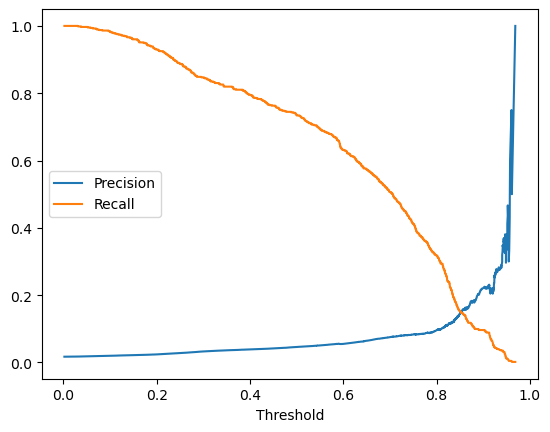

In [88]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

y_prob = xgb.predict_proba(X_test)[:, 1]
precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob)

plt.plot(thresholds, precisions[:-1], label='Precision')
plt.plot(thresholds, recalls[:-1], label='Recall')
plt.xlabel('Threshold')
plt.legend()
plt.show()